# RAG Evaluation

RAG evaluation focuses on measuring how well a Retrieval-Augmented Generation (RAG) system performs.
A RAG pipeline generally has two important stages:

```text
User Question
      ↓
Retriever
      ↓
Relevant Documents
      ↓
LLM
      ↓
Generated Answer
```
---

For evaluation, we check whether the system is:
- Correct — Is the generated answer correct?
- Relevant — Does the answer properly address the question?
- Grounded — Is the answer supported by the retrieved context?
- Retrieval Relevant — Did the retriever fetch the right information?
The goal is to evaluate both the retrieval process and the final generated response, rather than judging the chatbot's answer alone.
---

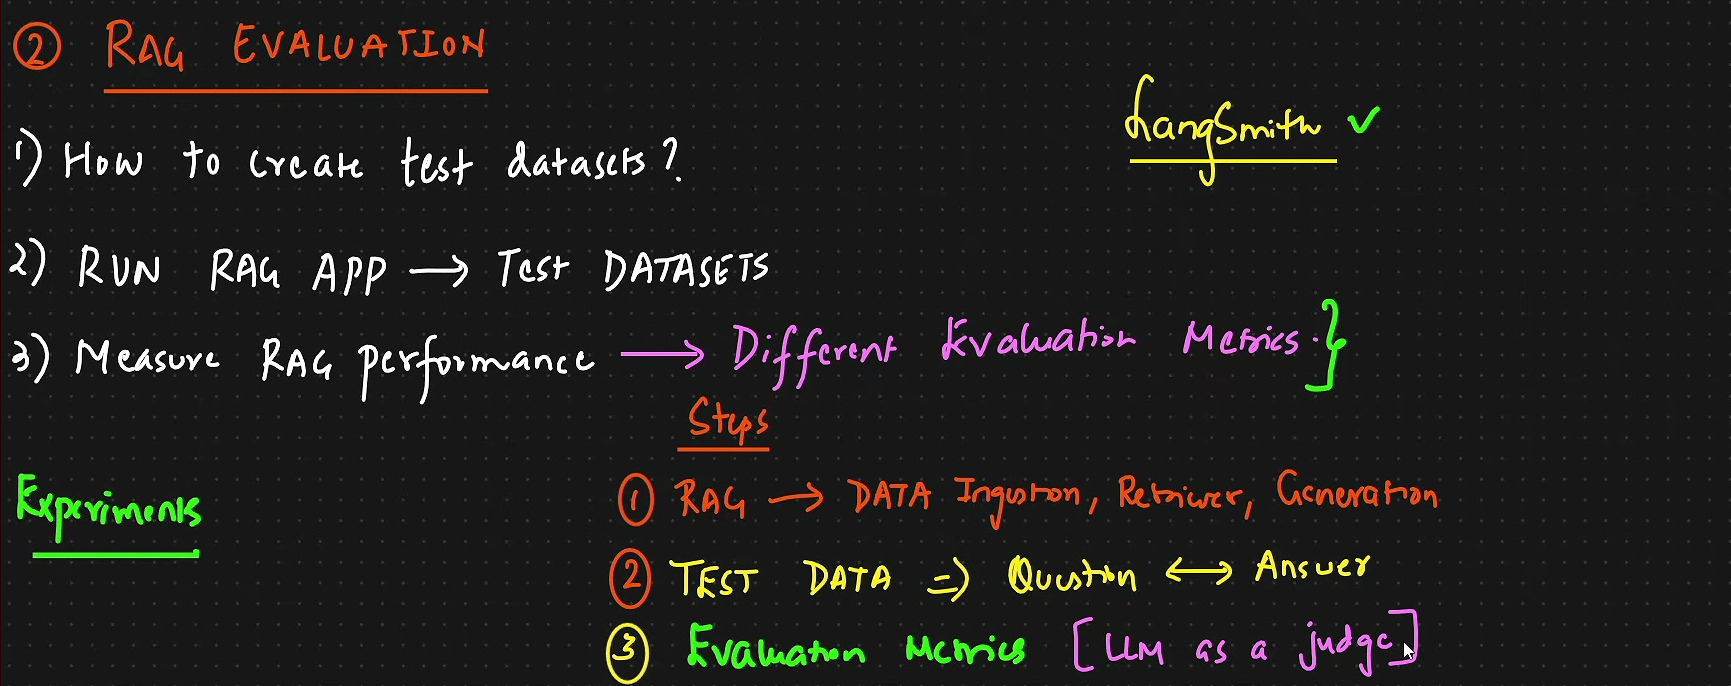

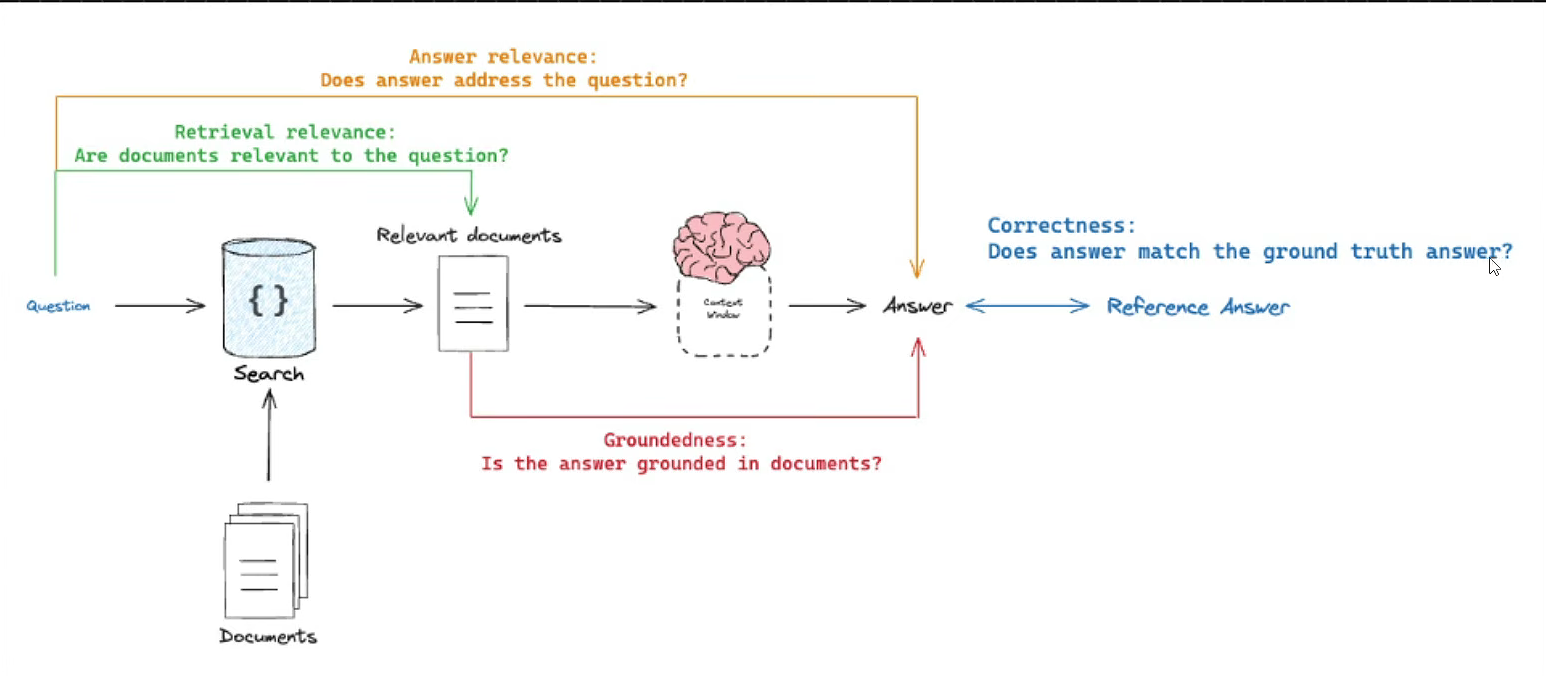

## Setup RAG Application

### Import Required Libraries
Since we're using Groq for the LLM side, the embeddings can be handled separately with Hugging Face embeddings.

In [2]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

C:\Users\devgo\AppData\Local\Temp\ipykernel_16012\1812030878.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WebBaseLoader
USER_AGENT environment variable not set, consider setting it to identify your requests.


### Load Documents from URLs

In [3]:
### List of URLs to load documents from
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
]

### Load documents from the URLs
docs = [WebBaseLoader(url).load() for url in urls]

docs_list = [
    item
    for sublist in docs
    for item in sublist
]

### Split Documents into Chunks

In [4]:
### Initialize a text splitter with specified chunk size and overlap
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=250,
    chunk_overlap=0
)

### Split the documents into chunks
doc_splits = text_splitter.split_documents(docs_list)

### Initialize Embeddings

In [5]:
embeddings = HuggingFaceEmbeddings(
    model_name="all-MiniLM-L6-v2"
)

d:\agentic-ai\05-Chatbot-and-RAG-Evaluation\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1483.45it/s]


### Create Vector Store

In [6]:
### Add the document chunks to the vector store
vectorstore = InMemoryVectorStore.from_documents(
    documents=doc_splits,
    embedding=embeddings,
)

### Create Retriever

In [7]:
### Convert the vector store into a retrieval component
retriever = vectorstore.as_retriever(
    search_kwargs={"k": 6}
)

### Test Document Retrieval

In [8]:
retriever.invoke("what is agents")

[Document(id='c88ebe7a-7317-481b-9776-fe002c4e0d3f', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, 

## Build the RAG Chatbot

### Initialize Groq Chat Model

In [9]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0
) 

### Add LangSmith Tracing

In [10]:
from langsmith import traceable

### Define the RAG Bot

In [11]:
@traceable()
def rag_bot(question: str) -> dict:

    # Relevant context
    docs = retriever.invoke(question)

    docs_string = " ".join(
        doc.page_content
        for doc in docs
    )

    instructions = f"""
You are a helpful assistant who is good at analyzing source information and answering questions.

Use the following source documents to answer the user's questions.

If you don't know the answer, just say that you don't know.

Use three sentences maximum and keep the answer concise.

Documents:
{docs_string}
"""

    # LLM invoke
    ai_msg = llm.invoke([
        {
            "role": "system",
            "content": instructions
        },
        {
            "role": "user",
            "content": question
        },
    ])

    return {
        "answer": ai_msg.content,
        "documents": docs
    }

### Test the RAG Bot

In [12]:
rag_bot("What is agents")

{'answer': 'In this context, an **agent** is a software entity whose behavior is driven by a large language model (LLM) that serves as its “brain.” The LLM receives observations, memory, and tool‑use inputs, then plans, decomposes tasks, reflects on past actions, and executes actions in an environment—often interacting with other agents. This architecture lets the agent act autonomously and adaptively, much like a virtual character or autonomous assistant.',
 'documents': [Document(id='c88ebe7a-7317-481b-9776-fe002c4e0d3f', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful

## Dataset

### Import LangSmith Client

In [13]:
from langsmith import Client

client = Client()

### Define Evaluation Examples

In [14]:
# Define the examples for the dataset
examples = [
    {
        "inputs": {
            "question": "How does the ReAct agent use self-reflection?"
        },
        "outputs": {
            "answer": "ReAct integrates reasoning and acting, performing actions - such tools like Wikipedia search API - and then observing / reasoning about the tool outputs."
        },
    },
    {
        "inputs": {
            "question": "What are the types of biases that can arise with few-shot prompting?"
        },
        "outputs": {
            "answer": "The biases that can arise with few-shot prompting include (1) Majority label bias, (2) Recency bias, and (3) Common token bias."
        },
    },
    {
        "inputs": {
            "question": "What are five types of adversarial attacks?"
        },
        "outputs": {
            "answer": "Five types of adversarial attacks are (1) Token manipulation, (2) Gradient based attack, (3) Jailbreak prompting, (4) Human red-teaming, (5) Model red-teaming."
        },
    }
]

### Create Dataset and Examples in LangSmith

In [16]:
dataset_name = "RAG Evaluation"

dataset = client.create_dataset(
    dataset_name=dataset_name
)

client.create_examples(
    dataset_id=dataset.id,
    examples=examples
)

{'example_ids': ['73a9c042-2856-40d5-b1a7-42db40dc0ace',
  'b2864c91-50fd-47fd-a4b3-f1f900cf9ad3',
  '0b3fc692-ba23-4704-a702-bf3a3273c9f8'],
 'count': 3,
 'as_of': '2026-10-08T15:52:57.223639183Z'}

## Define Evaluation Metrics (LLM as a Judge)

### Correctness: Response vs Reference Answer
- **Goal:** Measure "how similar/correct is the RAG chain answer, relative to a ground-truth answer"
- **Mode:** Requires a ground truth (reference) answer supplied through a dataset
- **Evaluator:** Use LLM-as-judge to assess answer correctness.

#### Define Correctness Output Schema

In [17]:
from typing_extensions import Annotated, TypedDict

# Grade output schema
class CorrectnessGrade(TypedDict):
    # Explanation is generated before the final score
    explanation: Annotated[
        str,
        ...,
        "Explain your reasoning for the score"
    ]

    correct: Annotated[
        bool,
        ...,
        "True if the answer is correct, False otherwise."
    ]

#### Define Correctness Evaluation Prompt

In [18]:
correctness_instructions = """
You are a teacher grading a quiz.

You will be given a QUESTION, the GROUND TRUTH (correct) ANSWER,
and the STUDENT ANSWER.

Here is the grade criteria to follow:

(1) Grade the student answers based ONLY on their factual accuracy
relative to the ground truth answer.

(2) Ensure that the student answer does not contain any conflicting statements.

(3) It is OK if the student answer contains more information than
the ground truth answer, as long as it is factually accurate relative
to the ground truth answer.

Correctness:

A correctness value of True means that the student's answer meets
all of the criteria.

A correctness value of False means that the student's answer does
not meet all of the criteria.

Explain your reasoning in a step-by-step manner to ensure your
reasoning and conclusion are correct.

Avoid simply stating the correct answer at the outset.
"""

#### Initialize Groq Grader

In [19]:
from langchain_groq import ChatGroq

grader_llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0
).with_structured_output(
    CorrectnessGrade,
    method="json_schema"
)

#### Define Correctness Evaluator

In [20]:
def correctness(
    inputs: dict,
    outputs: dict,
    reference_outputs: dict
) -> bool:
    """An evaluator for RAG answer accuracy"""

    answers = f"""
QUESTION: {inputs['question']}

GROUND TRUTH ANSWER: {reference_outputs['answer']}

STUDENT ANSWER: {outputs['answer']}
"""

    # Run evaluator
    grade = grader_llm.invoke([
        {
            "role": "system",
            "content": correctness_instructions
        },
        {
            "role": "user",
            "content": answers
        }
    ])

    return grade["correct"]

Here Groq acts as the evaluation judge, while LangSmith will later use this correctness evaluator to score your RAG application.

### Relevance: Response vs Input
- **Goal:** Measure "how well does the generated response address the initial user input"
- **Mode:** Does not require reference answer, because it will compare the answer to the input question
- **Evaluator:** Use LLM-as-judge to assess answer relevance, helpfulness, etc.

The flow is similar to the correctness evaluator, but here we only look at the input question and generated answer.

Without a reference answer, we cannot evaluate factual accuracy. However, we can still evaluate relevance — whether the generated answer addresses the user's question.

#### Define Relevance Output Schema

In [21]:
# Grade output schema
class RelevanceGrade(TypedDict):
    explanation: Annotated[
        str,
        ...,
        "Explain your reasoning for the score"
    ]

    relevant: Annotated[
        bool,
        ...,
        "Provide the score on whether the answer addresses the question"
    ]

#### Define Relevance Evaluation Prompt

In [22]:
relevance_instructions = """
You are a teacher grading a quiz.

You will be given a QUESTION and a STUDENT ANSWER.

Here is the grade criteria to follow:

(1) Ensure the STUDENT ANSWER is concise and relevant to the QUESTION.

(2) Ensure the STUDENT ANSWER helps to answer the QUESTION.

Relevance:

A relevance value of True means that the student's answer meets
all of the criteria.

A relevance value of False means that the student's answer does
not meet all of the criteria.

Explain your reasoning in a step-by-step manner to ensure your
reasoning and conclusion are correct.

Avoid simply stating the correct answer at the outset.
"""

#### Initialize Groq Grader

In [23]:
from langchain_groq import ChatGroq

relevance_llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0
).with_structured_output(
    RelevanceGrade,
    method="json_schema"
)

#### Define Relevance Evaluator

In [24]:
def relevance(
    inputs: dict,
    outputs: dict
) -> bool:
    """A simple evaluator for RAG answer helpfulness."""

    answer = (
        f"QUESTION: {inputs['question']}\n"
        f"STUDENT ANSWER: {outputs['answer']}"
    )

    grade = relevance_llm.invoke([
        {
            "role": "system",
            "content": relevance_instructions
        },
        {
            "role": "user",
            "content": answer
        }
    ])

    return grade["relevant"]

**Key difference from Correctness:** relevance() does not require reference_outputs, because it evaluates whether the answer addresses the question rather than whether it matches a ground-truth answer.

### Groundedness: Response vs Retrieved Documents
- **Goal:** Measure "to what extent does the generated response agree with the retrieved context"
- **Mode:** Does not require reference answer, because it will compare the answer to the retrieved context
- **Evaluator:** Use LLM-as-judge to assess faithfulness, hallucinations, etc.

Another useful way to evaluate responses without needing reference answers is to check whether the response is **justified by,** or **"grounded in,"** the retrieved documents.

#### Define Groundedness Output Schema

In [25]:
# Grade output schema
class GroundedGrade(TypedDict):
    explanation: Annotated[
        str,
        ...,
        "Explain your reasoning for the score"
    ]

    grounded: Annotated[
        bool,
        ...,
        "Provide the score on if the answer hallucinates from the documents"
    ]

#### Define Groundedness Evaluation Prompt

In [26]:
grounded_instructions = """
You are a teacher grading a quiz.

You will be given FACTS and a STUDENT ANSWER.

Here is the grade criteria to follow:

(1) Ensure the STUDENT ANSWER is grounded in the FACTS.

(2) Ensure the STUDENT ANSWER does not contain "hallucinated"
information outside the scope of the FACTS.

Grounded:

A grounded value of True means that the student's answer meets
all of the criteria.

A grounded value of False means that the student's answer does
not meet all of the criteria.

Explain your reasoning in a step-by-step manner to ensure your
reasoning and conclusion are correct.

Avoid simply stating the correct answer at the outset.
"""

#### Initialize Groq Grader

In [27]:
from langchain_groq import ChatGroq

grounded_llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0
).with_structured_output(
    GroundedGrade,
    method="json_schema"
)

#### Define Groundedness Evaluator

In [28]:
def groundedness(
    inputs: dict,
    outputs: dict
) -> bool:
    """A simple evaluator for RAG answer groundedness."""

    doc_string = "\n\n".join(
        doc.page_content
        for doc in outputs["documents"]
    )

    answer = (
        f"FACTS: {doc_string}\n"
        f"STUDENT ANSWER: {outputs['answer']}"
    )

    grade = grounded_llm.invoke([
        {
            "role": "system",
            "content": grounded_instructions
        },
        {
            "role": "user",
            "content": answer
        }
    ])

    return grade["grounded"]

Groundedness checks whether the generated answer stays within the information provided by the retrieved documents, helping identify hallucinated information.

### Retrieval Relevance: Retrieved Documents vs Input
- **Goal:** Measure "how relevant are my retrieved results for this query"
- **Mode:** Does not require reference answer, because it will compare the question to the retrieved context
- **Evaluator:** Use LLM-as-judge to assess relevance.

Retrieval relevance evaluates whether the retrieved documents (facts) are relevant to the user's question.

#### Define Retrieval Relevance Output Schema

In [29]:
# Grade output schema
class RetrievalRelevanceGrade(TypedDict):
    explanation: Annotated[
        str,
        ...,
        "Explain your reasoning for the score"
    ]

    relevant: Annotated[
        bool,
        ...,
        "True if the retrieved documents are relevant to the question, False otherwise"
    ]

#### Define Retrieval Relevance Evaluation Prompt

In [30]:
retrieval_relevance_instructions = """
You are a teacher grading a quiz.

You will be given a QUESTION and a set of FACTS provided by the student.

Here is the grade criteria to follow:

(1) Your goal is to identify FACTS that are completely unrelated to the QUESTION.

(2) If the facts contain ANY keywords or semantic meaning related to
the question, consider them relevant.

(3) It is OK if the facts have SOME information that is unrelated to
the question as long as (2) is met.

Relevance:

A relevance value of True means that the FACTS contain ANY keywords
or semantic meaning related to the QUESTION and are therefore relevant.

A relevance value of False means that the FACTS are completely
unrelated to the QUESTION.

Explain your reasoning in a step-by-step manner to ensure your
reasoning and conclusion are correct.

Avoid simply stating the correct answer at the outset.
"""

#### Initialize Groq Grader

In [31]:
from langchain_groq import ChatGroq

retrieval_relevance_llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0
).with_structured_output(
    RetrievalRelevanceGrade,
    method="json_schema"
)

#### Define Retrieval Relevance Evaluator

In [32]:
def retrieval_relevance(
    inputs: dict,
    outputs: dict
) -> bool:
    """An evaluator for document relevance"""

    doc_string = "\n\n".join(
        doc.page_content
        for doc in outputs["documents"]
    )

    answer = (
        f"FACTS: {doc_string}\n"
        f"QUESTION: {inputs['question']}"
    )

    # Run evaluator
    grade = retrieval_relevance_llm.invoke([
        {
            "role": "system",
            "content": retrieval_relevance_instructions
        },
        {
            "role": "user",
            "content": answer
        }
    ])

    return grade["relevant"]

Retrieval Relevance focuses specifically on the retrieval stage: whether the documents retrieved for a question contain information that is related to that question.

## Run Evaluation

### Define Evaluation Target

In [33]:
def target(inputs: dict) -> dict:
    return rag_bot(inputs["question"])

### Run RAG Evaluation

In [34]:
experiment_results = client.evaluate(
    target,
    data=dataset_name,
    evaluators=[
        correctness,
        groundedness,
        relevance,
        retrieval_relevance
    ],
    experiment_prefix="rag-doc-relevance",
    metadata={
        "version": "LCEL context, Groq"
    },
)

View the evaluation results for experiment: 'rag-doc-relevance-9b5d97c4' at:
https://smith.langchain.com/o/c899d496-c0ba-43c2-9aec-18f4af9446ab/datasets/74a7dd37-e26f-4d86-9914-a0e894e8f78b/compare?selectedSessions=7408a3f1-0cda-4e84-be19-814c56093b77




3it [01:29, 29.90s/it]


### Explore Evaluation Results
If pandas is installed, you can convert the evaluation results into a DataFrame:

In [35]:
experiment_results

,inputs.question,outputs.answer,outputs.documents,error,reference.answer,feedback.correctness,feedback.groundedness,feedback.relevance,feedback.retrieval_relevance,execution_time,example_id,id
0,What are the types of biases that can arise wi...,Few‑shot prompting can suffer from **majority‑...,[page_content='Text: i'll bet the video game i...,None,The biases that can arise with few-shot prompt...,True,True,True,True,1.952051,0b3fc692-ba23-4704-a702-bf3a3273c9f8,01a11c38-7133-7e22-b07a-85abb3880666
1,What are five types of adversarial attacks?,The five types of adversarial attacks on LLMs ...,[page_content='Adversarial attacks are inputs ...,None,Five types of adversarial attacks are (1) Toke...,True,True,True,True,0.879979,73a9c042-2856-40d5-b1a7-42db40dc0ace,01a11c38-89e5-71f1-b66d-3c24e819f4e2
2,How does the ReAct agent use self-reflection?,The ReAct agent follows a “Thought → Action → ...,[page_content='Self-reflection is a vital aspe...,None,"ReAct integrates reasoning and acting, perform...",False,True,True,True,10.268737,b2864c91-50fd-47fd-a4b3-f1f900cf9ad3,01a11c38-f243-7951-a97d-4c3a164e0c6d


In [36]:
experiment_results.to_pandas()

,inputs.question,outputs.answer,outputs.documents,error,reference.answer,feedback.correctness,feedback.groundedness,feedback.relevance,feedback.retrieval_relevance,execution_time,example_id,id
0,What are the types of biases that can arise wi...,Few‑shot prompting can suffer from **majority‑...,[page_content='Text: i'll bet the video game i...,None,The biases that can arise with few-shot prompt...,True,True,True,True,1.952051,0b3fc692-ba23-4704-a702-bf3a3273c9f8,01a11c38-7133-7e22-b07a-85abb3880666
1,What are five types of adversarial attacks?,The five types of adversarial attacks on LLMs ...,[page_content='Adversarial attacks are inputs ...,None,Five types of adversarial attacks are (1) Toke...,True,True,True,True,0.879979,73a9c042-2856-40d5-b1a7-42db40dc0ace,01a11c38-89e5-71f1-b66d-3c24e819f4e2
2,How does the ReAct agent use self-reflection?,The ReAct agent follows a “Thought → Action → ...,[page_content='Self-reflection is a vital aspe...,None,"ReAct integrates reasoning and acting, perform...",False,True,True,True,10.268737,b2864c91-50fd-47fd-a4b3-f1f900cf9ad3,01a11c38-f243-7951-a97d-4c3a164e0c6d


## LangSmith Evaluation Results

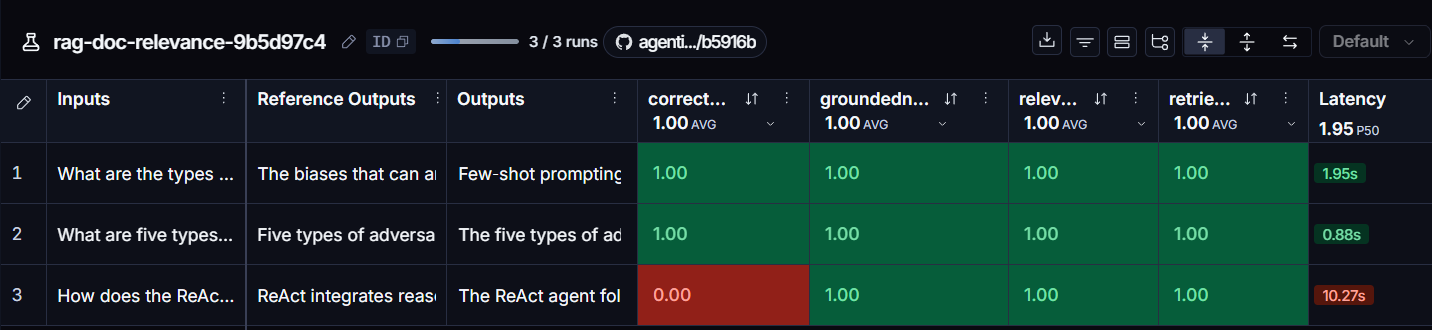

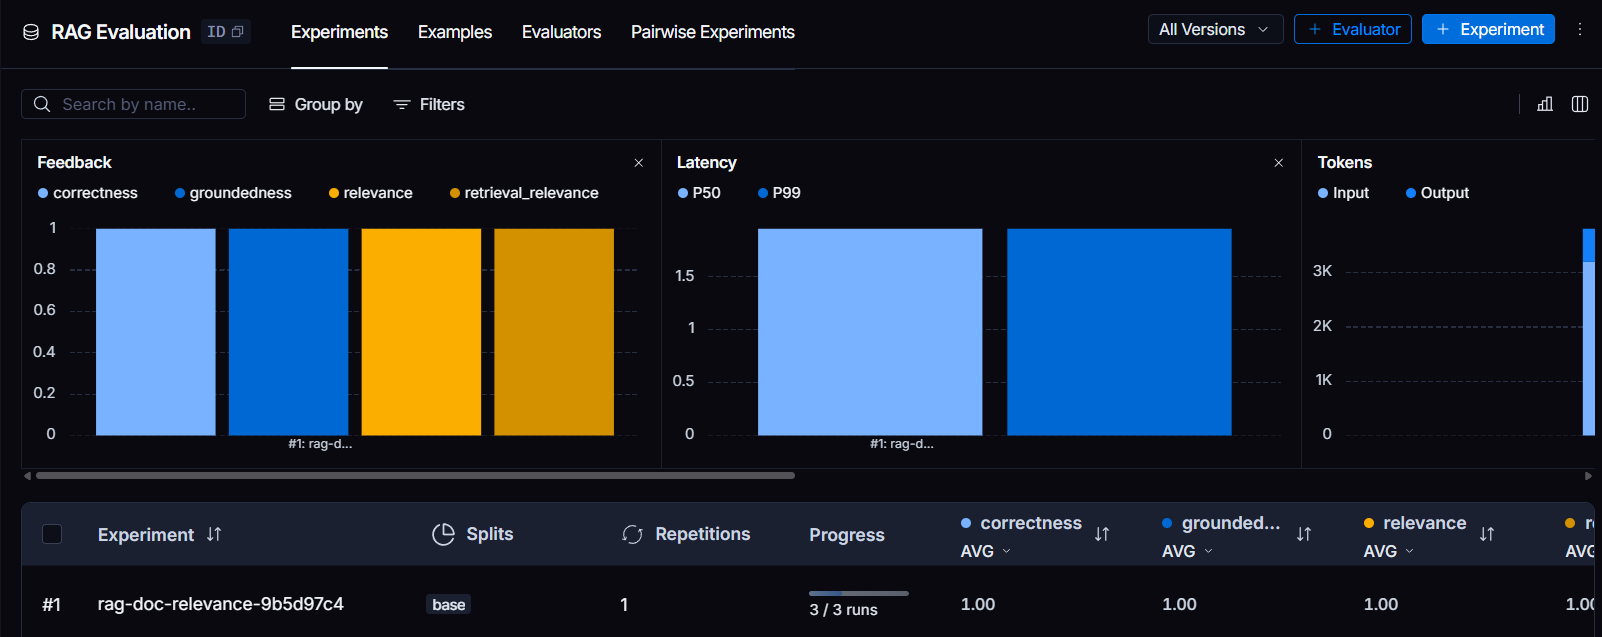